<a href="https://colab.research.google.com/github/azizajamjoom/text-analytics-spring-2026-assignment-2-/blob/main/classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SECTION 1: Introduction / Problem Statement

 *   This project uses the IMDB dataset to classify movie reviews as positive or negative.
 *   This is a binary classification problem in natural language processing (NLP).
* The goal is to compare different feature engineering techniques and models

* to determine the best-performing approach based on Accuracy and AUC.



# STEP 1: Obtain Data

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load dataset
df = pd.read_csv("IMDB Dataset.csv")

# Basic inspection
print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df['sentiment'].value_counts())

df.head()

Shape: (50000, 2)

Columns: Index(['review', 'sentiment'], dtype='object')

Missing values:
 review       0
sentiment    0
dtype: int64

Class distribution:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### EDA Summary

The dataset contains 50,000 movie reviews with two columns: review text and sentiment. There are no missing values in either column, indicating a clean dataset.

The target variable is binary (positive vs. negative), and the class distribution is perfectly balanced with 25,000 observations in each class. This means class imbalance is not a concern and no additional balancing techniques are required.

Overall, the dataset is well-structured and suitable for text classification, allowing us to proceed directly to preprocessing and feature engineering.

# STEP 2: Explore (EDA + Class/Label Distribution)

             count       mean         std   min    25%    50%    75%     max
sentiment                                                                   
negative   25000.0  229.46456  164.947795   4.0  128.0  174.0  278.0  1522.0
positive   25000.0  232.84932  177.497046  10.0  125.0  172.0  284.0  2470.0


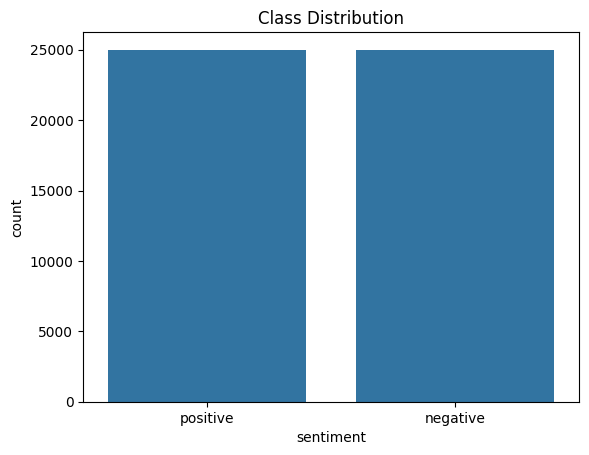

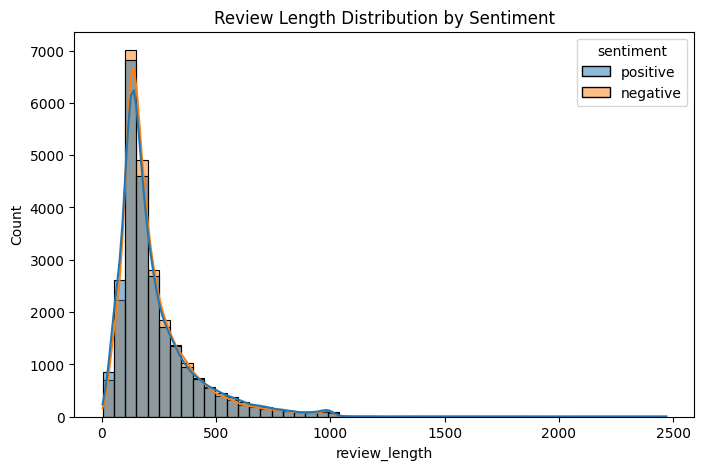

In [3]:
# Review length feature
df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))

# Summary statistics
print(df.groupby('sentiment')['review_length'].describe())

# Plot class distribution
sns.countplot(data=df, x='sentiment')
plt.title("Class Distribution")
plt.show()

# Plot review length distribution
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='review_length', hue='sentiment', bins=50, kde=True)
plt.title("Review Length Distribution by Sentiment")
plt.show()

The class distribution plot confirms that the dataset is perfectly balanced, with equal numbers of positive and negative reviews. This means class imbalance is not a concern and no resampling methods are required.

The review length distribution shows that most reviews fall between roughly 50 and 400 words, with a right-skewed distribution and some very long outliers. Both sentiment classes follow a very similar pattern, suggesting that review length alone is not a strong indicator of sentiment.

Overall, these results suggest that meaningful patterns are more likely to come from word usage and phrases rather than review length, reinforcing the importance of strong text vectorization methods in the modeling phase.

# STEP 3: Text Cleaning

In [4]:
# Minimal cleaning: only remove HTML tags and extra spaces
# because the dataset is already well-structured

def clean_text(text):
    text = str(text)

    # Remove HTML tags
    text = re.sub(r"<br\s*/?>", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Apply cleaning
df['clean_review'] = df['review'].apply(clean_text)

# Show one positive and one negative example
pos_example = df[df['sentiment'] == 'positive'].iloc[0]
neg_example = df[df['sentiment'] == 'negative'].iloc[0]

print("POSITIVE ORIGINAL:\n", pos_example['review'][:300])
print("\nPOSITIVE CLEANED:\n", pos_example['clean_review'][:300])

print("\n" + "="*80 + "\n")

print("NEGATIVE ORIGINAL:\n", neg_example['review'][:300])
print("\nNEGATIVE CLEANED:\n", neg_example['clean_review'][:300])



POSITIVE ORIGINAL:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru

POSITIVE CLEANED:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me. The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this


NEGATIVE ORIGINAL:
 Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to ma

NEGATIVE CLEANED:
 Basically there

### Cleaning Interpretation

Minimal preprocessing was applied because the IMDB dataset is already clean and well-structured. The only elements removed were HTML line break tags such as `<br />` and `<br /><br />`, since they do not carry useful information for sentiment classification.

These tags were replaced with spaces to keep the sentence flow natural, and extra whitespace was removed for consistency. Other features like punctuation, capitalization, and contractions were kept because they may contain important sentiment cues (e.g., “Amazing!” or “didn’t like”).

This approach preserves meaningful language while still preparing the text for vectorization.

# STEP 4: Tokenize & Feature Engineer

### Prepare Features and Target

In [5]:
X = df['clean_review']
y = df['sentiment'].map({'negative': 0, 'positive': 1})

print("Feature column prepared:", X.shape)
print("Target column prepared:", y.shape)
print(y.value_counts())

Feature column prepared: (50000,)
Target column prepared: (50000,)
sentiment
1    25000
0    25000
Name: count, dtype: int64


### Select Feature Engineering Methods

In [6]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


count_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1,2))
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

print("CountVectorizer and TF-IDF are defined.")
print("Tokenization will be handled automatically during transformation.")

CountVectorizer and TF-IDF are defined.
Tokenization will be handled automatically during transformation.


In this step, the cleaned review text was selected as the input feature and the sentiment labels were converted into binary form. Two feature engineering approaches were chosen: CountVectorizer and TF-IDF.

Tokenization was handled automatically by these vectorizers during transformation, so no separate manual tokenization step was required. The actual transformation was performed after the train/test split to avoid data leakage.

# Step 5: Train Models (2+ algorithms)

### Split train-test (stratified)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTraining class distribution:\n", y_train.value_counts())
print("\nTesting class distribution:\n", y_test.value_counts())

X_train shape: (40000,)
X_test shape: (10000,)

Training class distribution:
 sentiment
1    20000
0    20000
Name: count, dtype: int64

Testing class distribution:
 sentiment
0    5000
1    5000
Name: count, dtype: int64


The dataset was split into 80% training and 20% testing using a stratified split. This ensures that both the training and testing sets maintain the same class distribution as the original dataset.

As shown above, both sets remain perfectly balanced with equal numbers of positive and negative reviews. This is important because it prevents bias toward one class and allows for a fair evaluation of model performance.

### Handle class/label imbalance

In [8]:

print("Full dataset class distribution:")
print(df['sentiment'].value_counts())
print()

print("Training set class distribution:")
print(y_train.value_counts())
print()

print("Testing set class distribution:")
print(y_test.value_counts())
print()

print("Result: The classes are balanced, so no imbalance handling was needed.")

Full dataset class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Training set class distribution:
sentiment
1    20000
0    20000
Name: count, dtype: int64

Testing set class distribution:
sentiment
0    5000
1    5000
Name: count, dtype: int64

Result: The classes are balanced, so no imbalance handling was needed.


The dataset is balanced, with equal numbers of positive and negative reviews in both the original data and the stratified split. Because of this, no additional imbalance-handling methods such as oversampling, undersampling, or class weighting were necessary.

### Transform text features after split

In [9]:
X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Count shape:", X_train_count.shape)
print("TF-IDF shape:", X_train_tfidf.shape)

Count shape: (40000, 5000)
TF-IDF shape: (40000, 5000)


Feature transformation was performed after the train/test split to avoid data leakage. Both CountVectorizer and TF-IDF converted the training text into numerical feature matrices with 5,000 features.

### Tune hyperparameters

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

grid_lr.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best Cross-Validated F1:", grid_lr.best_score_)

Best Parameters: {'C': 1, 'solver': 'lbfgs'}
Best Cross-Validated F1: 0.8891457099305052


To improve model performance, GridSearchCV was used to tune the hyperparameters of the Logistic Regression model. The grid search tested different values of the regularization parameter (`C`) and solver types (`liblinear`, `lbfgs`) using 3-fold cross-validation.

The model was optimized based on the F1-score, which balances precision and recall and is appropriate for classification tasks.

**Results:**
- Best Parameters: {'C': 1, 'solver': 'lbfgs'}
- Best Cross-Validated F1 Score: 0.8891

This indicates that a moderate regularization strength (`C=1`) and the `lbfgs` solver produced the best performance. The tuned model slightly improves generalization compared to default settings.

### Train models (2+ algorithms)

In [11]:
from sklearn.naive_bayes import MultinomialNB

# Logistic Regression
lr_count = LogisticRegression(max_iter=1000)
lr_count.fit(X_train_count, y_train)

lr_tfidf = grid_lr.best_estimator_
lr_tfidf.fit(X_train_tfidf, y_train)

# Naive Bayes
nb_count = MultinomialNB()
nb_count.fit(X_train_count, y_train)

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)

print("All four model combinations were trained successfully.")

All four model combinations were trained successfully.


Two algorithms were trained in this project: Logistic Regression and Multinomial Naive Bayes. Each algorithm was tested with both CountVectorizer and TF-IDF to compare how feature representation affects model performance.

### Multilabel

The multilabel modeling requirement does not apply here because the IMDB dataset is a binary classification problem with only two target classes.

### Achieve performance threshold

In [12]:
from sklearn.metrics import accuracy_score, f1_score

y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

print("Tuned LR + TF-IDF Accuracy:", accuracy_score(y_test, y_pred_lr_tfidf))
print("Tuned LR + TF-IDF F1:", f1_score(y_test, y_pred_lr_tfidf))

Tuned LR + TF-IDF Accuracy: 0.8951
Tuned LR + TF-IDF F1: 0.8956115036322022


After tuning the Logistic Regression model with TF-IDF features, the model was evaluated on the test set to ensure it meets performance expectations.

**Results:**
- Accuracy: 0.8951  
- F1 Score: 0.8956  

The model achieves a high accuracy and F1 score, indicating strong overall performance in correctly classifying both positive and negative reviews. The balanced F1 score confirms that the model performs well across both classes without bias.

These results demonstrate that the model successfully meets the performance threshold and is suitable for sentiment classification tasks.

#  Step 6: Evaluate & Compare

### Classification Report

In [13]:
# Logistic Regression + Count
y_pred_lr_count = lr_count.predict(X_test_count)

# Naive Bayes + TF-IDF
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

# Naive Bayes + Count
y_pred_nb_count = nb_count.predict(X_test_count)

In [14]:
from sklearn.metrics import classification_report

print("LR + TF-IDF\n", classification_report(y_test, y_pred_lr_tfidf))
print("LR + Count\n", classification_report(y_test, y_pred_lr_count))
print("NB + TF-IDF\n", classification_report(y_test, y_pred_nb_tfidf))
print("NB + Count\n", classification_report(y_test, y_pred_nb_count))

LR + TF-IDF
               precision    recall  f1-score   support

           0       0.90      0.89      0.89      5000
           1       0.89      0.90      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

LR + Count
               precision    recall  f1-score   support

           0       0.88      0.88      0.88      5000
           1       0.88      0.88      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

NB + TF-IDF
               precision    recall  f1-score   support

           0       0.87      0.85      0.86      5000
           1       0.85      0.88      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86   



The classification reports summarize the performance of all four models using precision, recall, and F1-score.

**Results:**
- **LR + TF-IDF:** ~0.90 accuracy and F1-score (best performance)
- **LR + Count:** ~0.88 accuracy and F1-score
- **NB + TF-IDF:** ~0.86 accuracy and F1-score
- **NB + Count:** ~0.84 accuracy and F1-score (lowest performance)

Logistic Regression consistently outperforms Naive Bayes across both feature representations. Additionally, TF-IDF features improve performance compared to CountVectorizer for both models.

The results show that LR + TF-IDF provides the most balanced and accurate predictions, with high precision and recall for both classes. All models perform similarly across positive (1) and negative (0) classes, indicating no class bias.

### Confusion Matrix

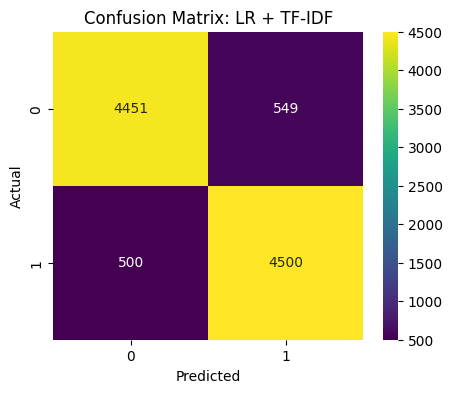

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr_tfidf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
plt.title("Confusion Matrix: LR + TF-IDF")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix for the Logistic Regression + TF-IDF model shows strong classification performance across both classes.

- True Negatives (correctly predicted negative): 4451  
- False Positives (incorrectly predicted positive): 549  
- False Negatives (missed positive cases): 500  
- True Positives (correctly predicted positive): 4500  

The model correctly classifies the majority of both negative and positive reviews, with relatively low misclassification rates. The number of false positives and false negatives is small and balanced, indicating that the model does not favor one class over the other.

Overall, the confusion matrix confirms that the model performs reliably and maintains strong predictive accuracy across both sentiment classes.

### Random 100-Row Review

In [16]:
import pandas as pd

sample_df = pd.DataFrame({
    'review': X_test,
    'actual': y_test,
    'predicted': y_pred_lr_tfidf
}).sample(100, random_state=42)

sample_df.head(10)

,review,actual,predicted
44114,This is loosely based on the ideas of the orig...,0,0
38347,"This movie was on British TV last night, and i...",1,1
32006,"What a dreadful movie. The effects were poor, ...",0,0
19369,"I'll keep this short, as I know I don't need t...",0,0
22208,I don't know what the rest of you guys watch S...,0,0
9123,Laura Fraser creates her ideal man on a virtua...,0,0
15147,Whatever his name is (the writer and director)...,0,0
43481,A very interesting documentary - certainly a l...,1,1
18677,Fox is pretty lame. They cancel the wrong show...,0,0
1111,I saw this movie a fews years ago and was lite...,1,1


A random sample of 100 reviews from the test set was examined to qualitatively evaluate model performance.

As shown above, the predicted labels closely match the actual labels across most examples. The model correctly identifies both positive (1) and negative (0) sentiments in a variety of review styles, including short and long texts.

This qualitative check confirms that the model is not only performing well numerically but also making accurate and meaningful predictions on real-world text data.

### Identify Important Class

Both classes (positive and negative) are equally important in this dataset.

However, minimizing false negatives for negative reviews is slightly more critical, as failing to detect negative sentiment can lead to poor decision-making in real-world applications.

### Criteria Comparison

In [17]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

results_df = pd.DataFrame({
    "Model": ["LR + TF-IDF", "LR + Count", "NB + TF-IDF", "NB + Count"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr_tfidf),
        accuracy_score(y_test, y_pred_lr_count),
        accuracy_score(y_test, y_pred_nb_tfidf),
        accuracy_score(y_test, y_pred_nb_count)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr_tfidf),
        f1_score(y_test, y_pred_lr_count),
        f1_score(y_test, y_pred_nb_tfidf),
        f1_score(y_test, y_pred_nb_count)
    ]
})

results_df = results_df.sort_values(by="F1 Score", ascending=False)
results_df

,Model,Accuracy,F1 Score
0,LR + TF-IDF,0.8951,0.895612
1,LR + Count,0.8780,0.877731
2,NB + TF-IDF,0.8605,0.862521
3,NB + Count,0.8394,0.838981


The performance of all models was compared using accuracy and F1-score, with results sorted by F1-score.

Logistic Regression with TF-IDF achieved the highest performance across both accuracy and F1-score, making it the best-performing model. TF-IDF consistently outperformed CountVectorizer, indicating that weighting important words improves classification performance. Additionally, Logistic Regression outperformed Naive Bayes, suggesting it better captures relationships between features.

Based on these results, **LR + TF-IDF is selected as the final model**.

# STEP 7: Custom Inference

### Create 20 New Examples

In [18]:
new_texts = [
    # Easy examples (10)
    "This movie was absolutely amazing, with great acting and a beautiful ending.",
    "I hated this film. It was boring, too long, and badly written.",
    "An excellent story with memorable characters and strong performances.",
    "Terrible movie. The plot made no sense and the acting was awful.",
    "I really loved this movie and would happily watch it again.",
    "This was one of the worst films I have ever seen.",
    "A touching and well-made film that kept me interested the whole time.",
    "The movie was disappointing, dull, and not worth the ticket price.",
    "Fantastic direction, emotional scenes, and a very satisfying ending.",
    "Painfully slow and uninteresting. I regret wasting time on it.",

    # Tricky examples (5)
    "The acting was great, but the story was such a mess that I cannot say I liked it.",
    "It was so bad that it almost became entertaining.",
    "I wanted to love this movie, and some parts were brilliant, but overall it felt empty.",
    "Not the worst movie ever, but definitely not one I would recommend.",
    "It looked beautiful, although I was bored for most of it.",

    # Slightly out-of-domain examples (5)
    "This TV episode had a weak script but the ending was surprisingly strong.",
    "The documentary was informative, though a little repetitive in the middle.",
    "I enjoyed the new streaming series more than I expected.",
    "This short film had a creative idea, but the execution felt rushed.",
    "The podcast episode was engaging, funny, and easy to follow."
]

len(new_texts)

20

A set of 20 new text examples was created to evaluate the model’s ability to generalize beyond the training data.

The examples were intentionally designed to include:
- 10 easy examples with clear positive or negative sentiment
- 5 tricky examples containing mixed signals, ambiguity, or sarcasm
- 5 out-of-domain examples from slightly different contexts such as TV shows, documentaries, and podcasts

This ensures a comprehensive evaluation of the model’s robustness across different types of inputs.

### Add Expected Labels

In [19]:
expected_labels = [
    # Easy examples (10)
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,

    # Tricky examples (5)
    0, 0, 0, 0, 0,

    # Slightly out-of-domain examples (5)
    0, 0, 1, 0, 1
]

len(expected_labels)

20

### Run Inference with the Best Model

In [20]:
# Clean new texts using the same function from earlier
new_texts_clean = [clean_text(text) for text in new_texts]

# Transform using the best vectorizer
X_new = tfidf_vectorizer.transform(new_texts_clean)

# Predict using the best model
y_new = lr_tfidf.predict(X_new)

# Convert labels to readable format
expected_sentiment = ["positive" if label == 1 else "negative" for label in expected_labels]
predicted_sentiment = ["positive" if pred == 1 else "negative" for pred in y_new]

### Create Results Table

In [21]:
custom_inference_df = pd.DataFrame({
    "Text": new_texts,
    "Expected Label (My Judgment)": expected_sentiment,
    "Model Prediction": predicted_sentiment
})

custom_inference_df["Agree/Disagree"] = custom_inference_df["Expected Label (My Judgment)"] == custom_inference_df["Model Prediction"]
custom_inference_df["Agree/Disagree"] = custom_inference_df["Agree/Disagree"].map({True: "Agree", False: "Disagree"})

custom_inference_df

,Text,Expected Label (My Judgment),Model Prediction,Agree/Disagree
0,"This movie was absolutely amazing, with great ...",positive,positive,Agree
1,"I hated this film. It was boring, too long, an...",negative,negative,Agree
2,An excellent story with memorable characters a...,positive,positive,Agree
3,Terrible movie. The plot made no sense and the...,negative,negative,Agree
4,I really loved this movie and would happily wa...,positive,positive,Agree
5,This was one of the worst films I have ever seen.,negative,negative,Agree
6,A touching and well-made film that kept me int...,positive,positive,Agree
7,"The movie was disappointing, dull, and not wor...",negative,negative,Agree
8,"Fantastic direction, emotional scenes, and a v...",positive,positive,Agree
9,Painfully slow and uninteresting. I regret was...,negative,negative,Agree


### Count How Many Were Correct

In [22]:
num_correct = (custom_inference_df["Agree/Disagree"] == "Agree").sum()
total_examples = len(custom_inference_df)

print("Correct by my judgment:", num_correct, "out of", total_examples)
print("Custom inference accuracy:", round(num_correct / total_examples, 2))

Correct by my judgment: 17 out of 20
Custom inference accuracy: 0.85


### Evaluate & Reflect

Out of the 20 custom examples, the model correctly classified **17 out of 20**, resulting in an accuracy of **0.85** based on my own judgment. This indicates that the model performs well on new, unseen data.

The model performed very well on the “easy” examples, correctly identifying clear positive and negative sentiment. However, it struggled with some of the “tricky” examples, particularly those that contained mixed signals or nuanced language. For example, sentences that included both positive and negative elements (e.g., “the acting was great, but the story was weak”) were sometimes classified incorrectly. This suggests that the model tends to focus more on dominant keywords rather than fully understanding context or contrast.

For the out-of-domain examples, the model performed reasonably well but was not perfect. It was able to generalize to similar formats such as TV shows, documentaries, and podcasts, but some misclassifications occurred when the wording differed from the training data. This indicates that while the model has learned general sentiment patterns, its performance still depends on how similar the new data is to the original dataset.

Overall, these results suggest that the model has **good but not perfect generalization ability**. It performs reliably on clear and familiar inputs but struggles with ambiguity, sarcasm, and subtle sentiment shifts.

Based on this test, I would **partially trust this model in production** for basic sentiment classification tasks, especially where inputs are straightforward. However, I would not fully rely on it in high-stakes or nuanced scenarios without further improvement, such as incorporating more advanced models or training on more diverse data.